# Credit Card Fraud Detection Using Logistic Regression

## Phase 1: Data Processing

### Objective
The objective of this phase is to prepare the dataset for machine learning by performing data cleaning, transformation, validation, and preprocessing. These steps ensure the data is consistent, accurate, and suitable for building a reliable fraud detection model.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("creditcard.csv")

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


## Reading the Dataset

The dataset is imported using the Pandas library. It contains historical credit card transactions, where the target variable **Class** indicates whether a transaction is legitimate (0) or fraudulent (1).

In [5]:
print("Dataset Shape:", df.shape)

Dataset Shape: (243625, 31)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243625 entries, 0 to 243624
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    243625 non-null  float64
 1   V1      243625 non-null  float64
 2   V2      243625 non-null  float64
 3   V3      243625 non-null  float64
 4   V4      243625 non-null  float64
 5   V5      243625 non-null  float64
 6   V6      243625 non-null  float64
 7   V7      243625 non-null  float64
 8   V8      243625 non-null  float64
 9   V9      243625 non-null  float64
 10  V10     243625 non-null  float64
 11  V11     243625 non-null  float64
 12  V12     243625 non-null  float64
 13  V13     243625 non-null  float64
 14  V14     243625 non-null  float64
 15  V15     243625 non-null  float64
 16  V16     243625 non-null  float64
 17  V17     243625 non-null  float64
 18  V18     243625 non-null  float64
 19  V19     243625 non-null  float64
 20  V20     243625 non-null  float64
 21  V21     24

In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,243625.000000,243625.000000,243625.000000,243625.000000,243625.000000,243625.000000,243625.000000,243625.000000,243625.000000,243625.000000,...,243625.000000,243625.000000,243625.000000,243625.000000,243625.000000,243625.000000,243625.000000,243624.000000,243624.000000,243624.000000
mean,83546.097379,-0.046816,-0.019064,0.121713,0.031763,-0.044416,0.021544,-0.017619,0.001931,0.001519,...,-0.003357,-0.014375,-0.007359,0.000509,0.025758,0.001739,-0.000739,0.001097,91.094430,0.001814
std,41865.139925,1.959741,1.671252,1.503925,1.414478,1.376107,1.324645,1.228481,1.200353,1.115576,...,0.740469,0.714552,0.640448,0.606396,0.513798,0.486075,0.402113,0.333153,252.404185,0.042556
min,0.000000,-56.407510,-72.715728,-33.680984,-5.683171,-42.147898,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-11.710896,0.000000,0.000000
25%,49560.000000,-0.940826,-0.606729,-0.681459,-0.832297,-0.732466,-0.743591,-0.565103,-0.200126,-0.657003,...,-0.225629,-0.534085,-0.165677,-0.350279,-0.287118,-0.330499,-0.070424,-0.049851,6.000000,0.000000
50%,76329.000000,-0.012042,0.062972,0.311498,0.022683,-0.102021,-0.247182,0.018227,0.030054,-0.060943,...,-0.032253,-0.004549,-0.019437,0.045658,0.058590,-0.059384,0.002545,0.014487,23.370000,0.000000
75%,125520.000000,1.258054,0.781360,1.114847,0.807589,0.557214,0.424498,0.544121,0.330543,0.608606,...,0.175071,0.490761,0.133530,0.430369,0.367289,0.248901,0.088994,0.077854,79.990000,0.000000
max,152005.000000,2.454930,22.057729,9.382558,16.875344,34.801666,22.529298,36.877368,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.022866,7.519589,3.517346,12.152401,33.847808,19656.530000,1.000000


In [8]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [9]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [10]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 904


## Exploratory Data Analysis

The dataset was successfully loaded and explored to understand its structure and quality. It initially contained **243,625 transactions** and **31 features**, including anonymized variables (`V1`–`V28`), `Time`, `Amount`, and the target variable `Class`.

The exploratory analysis revealed that:
- The dataset is composed entirely of numerical features.
- A small number of missing values were found in the **V28**, **Amount**, and **Class** columns.
- **904 duplicate records** were identified.
- The transaction amount exhibits a wide range of values, suggesting the presence of potential outliers.

These observations guided the data preprocessing steps performed in the next section.

In [11]:
# Remove rows containing missing values
df = df.dropna()

# Verify that no missing values remain
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [12]:
# Remove duplicate rows
df = df.drop_duplicates()

# Verify duplicates were removed
print("Remaining Duplicate Rows:", df.duplicated().sum())

# Display the new dataset shape
print("New Dataset Shape:", df.shape)

Remaining Duplicate Rows: 0
New Dataset Shape: (242720, 31)


## Data Cleaning

The dataset was cleaned by removing rows containing missing values and eliminating duplicate records.

Only three missing values were detected across the dataset, so removing these rows had a negligible impact on the overall data size. Additionally, **904 duplicate transactions** were removed to improve data quality and prevent repeated observations from affecting the machine learning model.

After cleaning, the dataset contains **242,720 transactions** and **31 features**, with **no remaining missing values or duplicate records**.

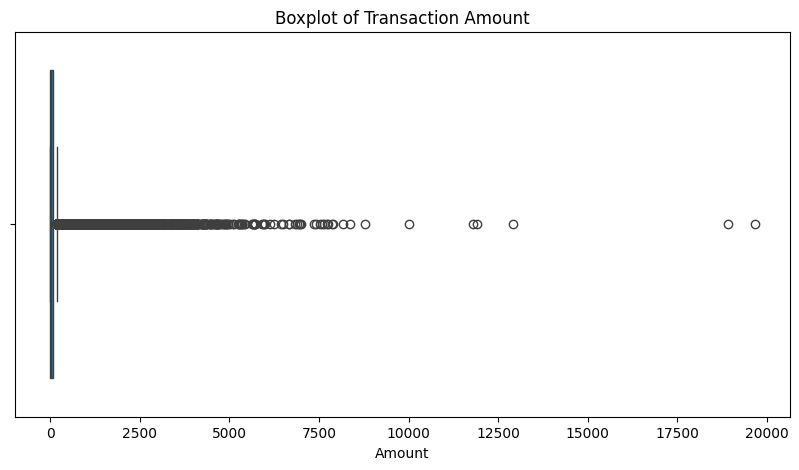

In [13]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df["Amount"])

plt.title("Boxplot of Transaction Amount")
plt.xlabel("Amount")

plt.show()

## Outlier Detection

The distribution of the **Amount** feature was examined using a boxplot. The visualization shows the presence of several extreme transaction values (outliers), while the majority of transactions are concentrated at lower amounts. Since high-value transactions are common in financial data and may represent legitimate customer activity, the outliers were retained instead of being removed to preserve important information.

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["Amount"] = scaler.fit_transform(df[["Amount"]])

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.231240,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.350310,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.137782,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.127857,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.083936,0.0


## Data Transformation

To prepare the dataset for machine learning, the **Amount** feature was standardized using the **StandardScaler** technique. Standardization transforms the values to have a mean close to zero and a standard deviation close to one. This preprocessing step is important because Logistic Regression performs better when numerical features are on a similar scale.

## Data Integration

The project uses a single dataset; therefore, no data integration from multiple data sources was required.

In [15]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:", df.isnull().sum().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

df.info()

Dataset Shape: (242720, 31)

Missing Values: 0

Duplicate Rows: 0
<class 'pandas.core.frame.DataFrame'>
Index: 242720 entries, 0 to 243623
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    242720 non-null  float64
 1   V1      242720 non-null  float64
 2   V2      242720 non-null  float64
 3   V3      242720 non-null  float64
 4   V4      242720 non-null  float64
 5   V5      242720 non-null  float64
 6   V6      242720 non-null  float64
 7   V7      242720 non-null  float64
 8   V8      242720 non-null  float64
 9   V9      242720 non-null  float64
 10  V10     242720 non-null  float64
 11  V11     242720 non-null  float64
 12  V12     242720 non-null  float64
 13  V13     242720 non-null  float64
 14  V14     242720 non-null  float64
 15  V15     242720 non-null  float64
 16  V16     242720 non-null  float64
 17  V17     242720 non-null  float64
 18  V18     242720 non-null  float64
 19  V19     242720 non-null  

## Data Validation

After completing the preprocessing steps, the dataset was validated to ensure its quality and integrity. The final dataset contains **242,720 transactions** and **31 numerical features**. All missing values and duplicate records have been successfully removed, resulting in a clean and consistent dataset that is ready for data visualization and machine learning.

# Phase 1 Summary

In this phase, the credit card transaction dataset was successfully prepared for further analysis. The data was explored to understand its structure, cleaned by removing missing values and duplicate records, and transformed by standardizing the **Amount** feature using **StandardScaler**. Outlier analysis showed the presence of high-value transactions, which were retained because they represent realistic financial behavior. Finally, the processed dataset was validated, confirming that it is complete, consistent, and ready for visualization and model development.

# Phase 2: Data Visualization

## Objective

The objective of this phase is to explore the processed dataset using visualizations in order to understand the distribution of the data, identify important patterns, and gain insights that may improve the fraud detection model.

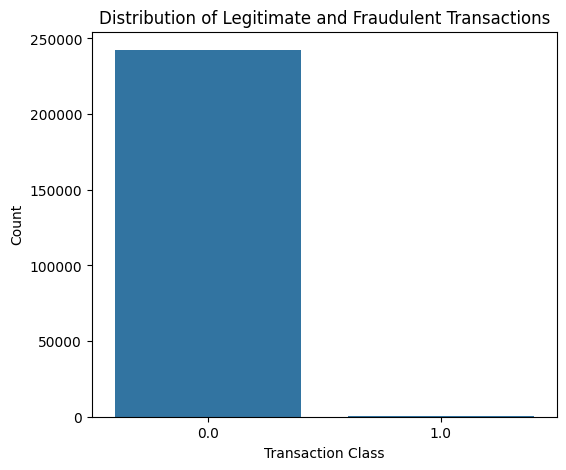

In [16]:
plt.figure(figsize=(6,5))

sns.countplot(x="Class", data=df)

plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Count")

plt.show()

## Distribution of Transaction Classes

The bar chart shows the distribution of legitimate and fraudulent transactions in the dataset. Most transactions belong to **Class 0 (legitimate transactions)**, while only a very small number belong to **Class 1 (fraudulent transactions)**. This indicates that the dataset is highly imbalanced, which is a common challenge in fraud detection and should be considered when evaluating the machine learning model.

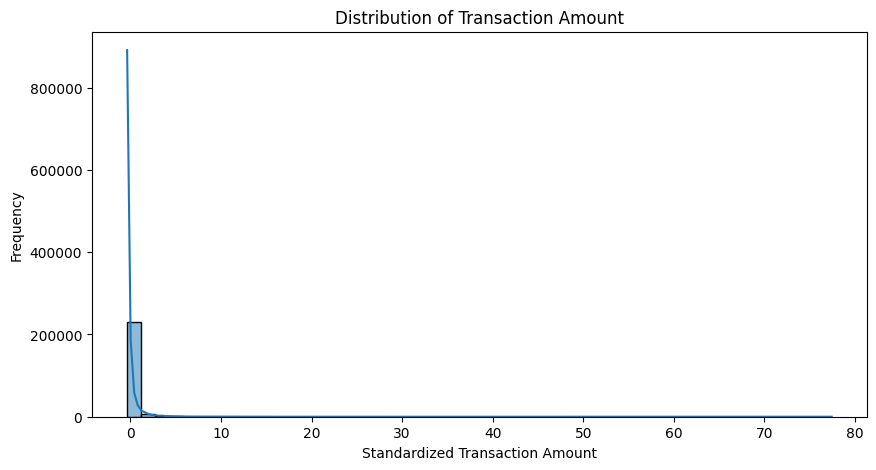

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(df["Amount"], bins=50, kde=True)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Standardized Transaction Amount")
plt.ylabel("Frequency")

plt.show()

## Distribution of Transaction Amount

The histogram shows the distribution of the standardized transaction amounts. Most transactions are concentrated around lower values, while a small number of transactions have much larger amounts, resulting in a right-skewed distribution. This pattern is common in financial transaction datasets, where low-value transactions are more frequent than high-value ones.

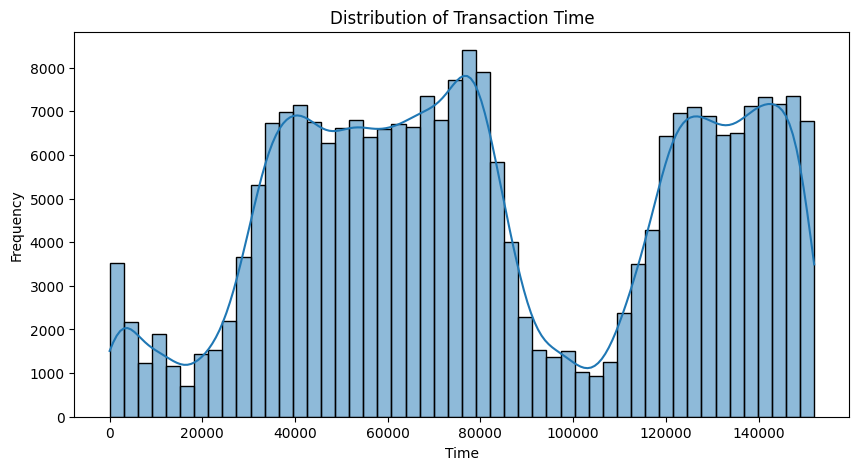

In [18]:
plt.figure(figsize=(10,5))

sns.histplot(df["Time"], bins=50, kde=True)

plt.title("Distribution of Transaction Time")
plt.xlabel("Time")
plt.ylabel("Frequency")

plt.show()

## Distribution of Transaction Time

The histogram illustrates the distribution of transaction times across the dataset. Transactions are spread throughout the observation period, although the frequency is not uniform. Some time intervals contain significantly more transactions than others, indicating variations in transaction activity over time.

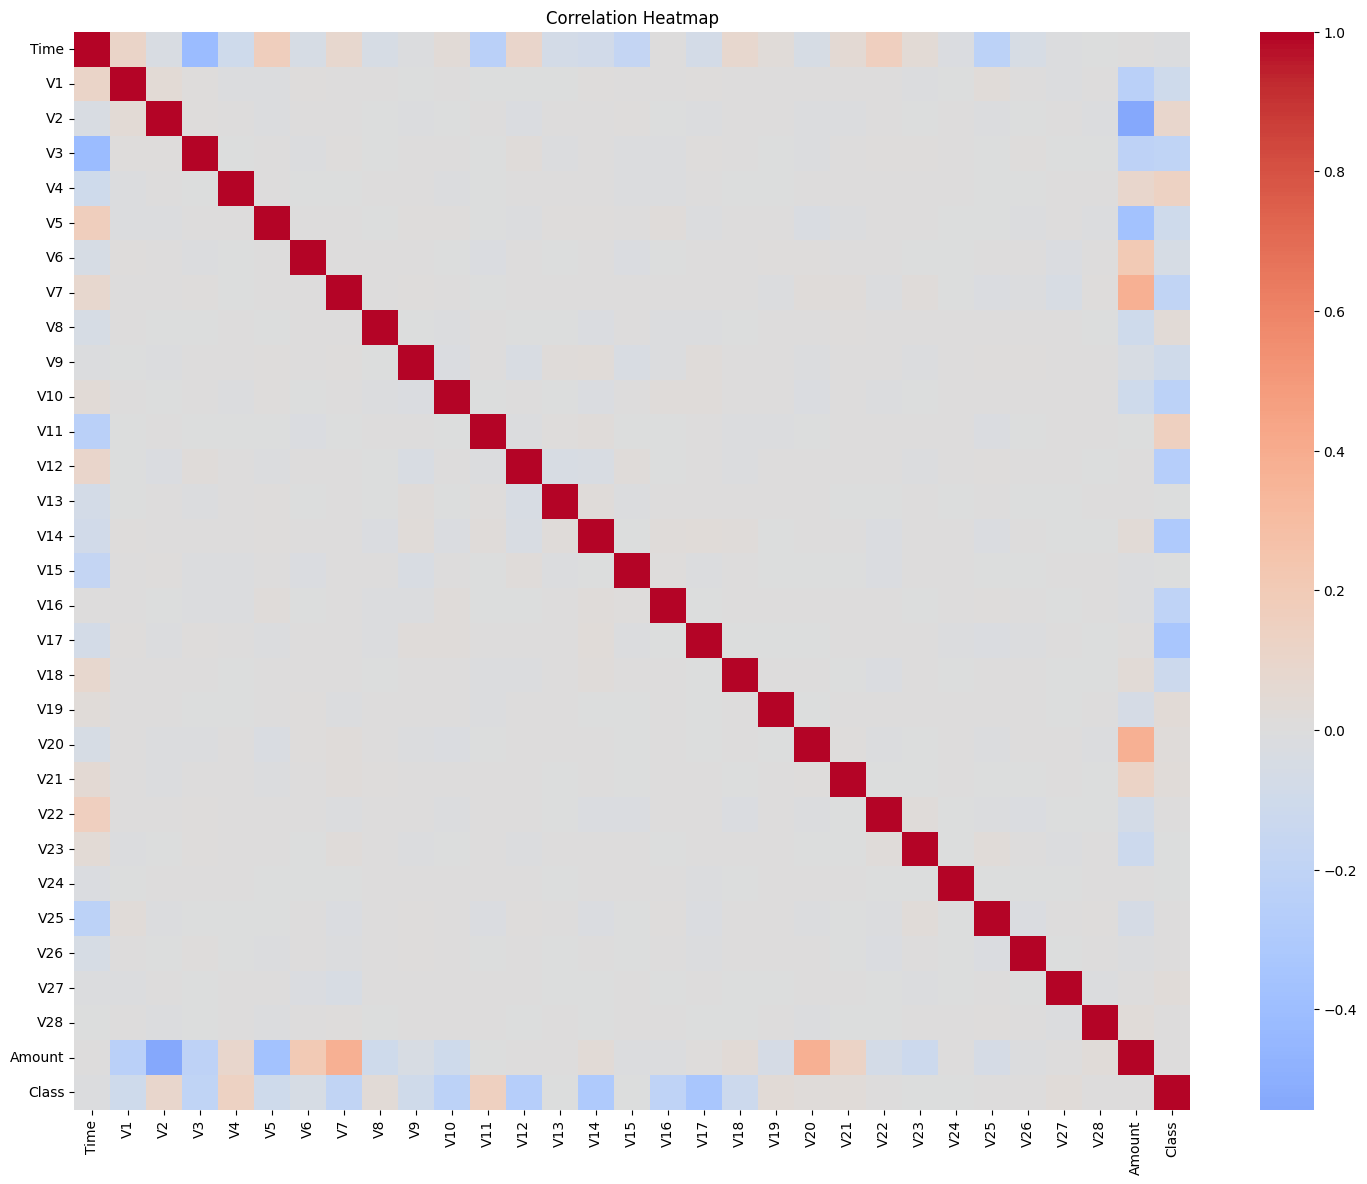

In [19]:
plt.figure(figsize=(18,14))

corr = df.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

## Correlation Heatmap

The correlation heatmap illustrates the relationships between the numerical features in the dataset. Most variables exhibit weak correlations with one another, indicating low multicollinearity. However, several features show noticeable positive or negative correlations with the target variable (`Class`), suggesting that they may contribute to identifying fraudulent transactions.

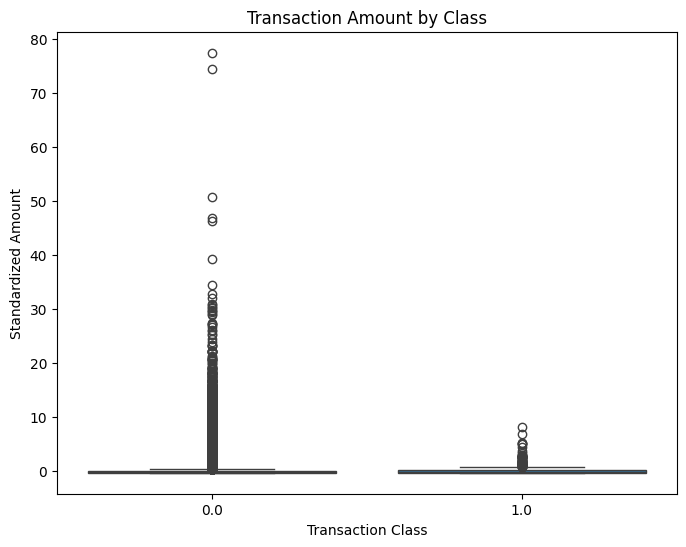

In [20]:
plt.figure(figsize=(8,6))

sns.boxplot(x="Class", y="Amount", data=df)

plt.title("Transaction Amount by Class")
plt.xlabel("Transaction Class")
plt.ylabel("Standardized Amount")

plt.show()

## Transaction Amount by Class

The boxplot compares the standardized transaction amounts for legitimate and fraudulent transactions. Both classes contain many low-value transactions; however, legitimate transactions exhibit a wider range of transaction amounts and more extreme outliers. Fraudulent transactions appear to be concentrated within a narrower range, suggesting that transaction amount alone is not sufficient to distinguish fraud but may still contribute to the predictive model when combined with other features.

# Phase 2 Summary

The visualizations provided valuable insights into the processed dataset. They revealed that the data is highly imbalanced, with legitimate transactions greatly outnumbering fraudulent ones. The transaction amount distribution is right-skewed, transaction activity varies over time, and most features exhibit weak correlations with one another. These findings will help guide the development and evaluation of the Logistic Regression model in the next phase.

# Phase 3: Model Building

## Objective

The objective of this phase is to build a Logistic Regression model capable of classifying credit card transactions as legitimate or fraudulent. The model will be trained on the processed dataset and evaluated using appropriate classification metrics to assess its performance.

In [21]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (242720, 30)
Target Shape: (242720,)


## Preparing the Features and Target Variable

Before training the model, the dataset was divided into the input features (**X**) and the target variable (**y**). The **Class** column was selected as the target variable because it indicates whether a transaction is legitimate (0) or fraudulent (1). The remaining 30 variables were used as input features for the Logistic Regression model.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (194176, 30)
Testing Set : (48544, 30)


## Splitting the Dataset

The dataset was divided into training and testing subsets using an **80/20 split**. A stratified split was applied to preserve the original distribution of legitimate and fraudulent transactions in both subsets. This approach ensures that the model is trained and evaluated on representative data, leading to a more reliable performance assessment.

In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Training the Logistic Regression Model

A Logistic Regression classifier was trained using the processed training dataset. The maximum number of iterations was set to **1000** to improve convergence during optimization. The model was successfully trained and is now ready to classify credit card transactions as either legitimate or fraudulent.

In [24]:
y_pred = model.predict(X_test)

print("Predictions completed!")

Predictions completed!


## Model Prediction

After training, the Logistic Regression model was used to predict the transaction classes for the testing dataset. These predictions were then used to evaluate the model's performance using several classification metrics.

In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-Score :", f1_score(y_test, y_pred))

Accuracy : 0.999073005932762
Precision: 0.8448275862068966
Recall   : 0.5764705882352941
F1-Score : 0.6853146853146853


## Model Performance Evaluation

The Logistic Regression model achieved an **accuracy of approximately 99.91%**, indicating that most transactions were classified correctly. Since the dataset is highly imbalanced, additional metrics were considered.

The model obtained a **precision of 84.48%**, meaning that most transactions predicted as fraudulent were indeed fraudulent. The **recall of 57.65%** indicates that the model detected more than half of the fraudulent transactions. The resulting **F1-score of 68.53%** reflects a reasonable balance between precision and recall for this fraud detection task.

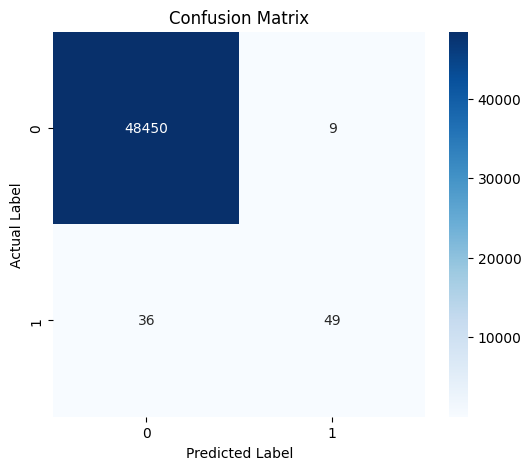

In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## Confusion Matrix

The confusion matrix provides a detailed summary of the model's predictions. The Logistic Regression model correctly classified **48,450 legitimate transactions** and **49 fraudulent transactions**. Only **9 legitimate transactions** were incorrectly flagged as fraud, while **36 fraudulent transactions** were not detected. These results demonstrate that the model performs very well in identifying legitimate transactions while maintaining a reasonable ability to detect fraudulent ones.

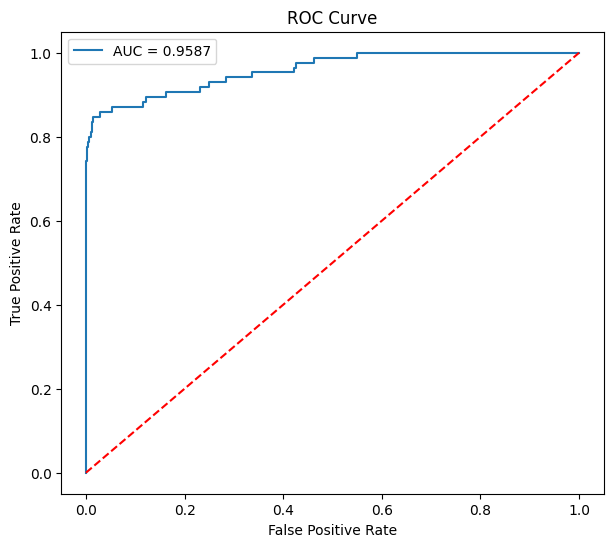

AUC Score: 0.9586782276830746


In [27]:
from sklearn.metrics import roc_curve, auc

# Predicted probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="red")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

print("AUC Score:", roc_auc)

## ROC Curve Analysis

The Receiver Operating Characteristic (ROC) curve was used to evaluate the model's ability to distinguish between legitimate and fraudulent transactions across different classification thresholds. The model achieved an **Area Under the Curve (AUC) score of 0.9587**, indicating excellent classification performance. An AUC value close to 1 demonstrates that the Logistic Regression model is highly effective at separating the two transaction classes.

# Phase 3 Summary

In this phase, a Logistic Regression model was successfully developed to detect fraudulent credit card transactions. The dataset was divided into training and testing subsets using an 80/20 stratified split to preserve the class distribution. The trained model was evaluated using multiple classification metrics, including accuracy, precision, recall, F1-score, the confusion matrix, and the ROC curve.

The model achieved an accuracy of **99.91%**, a precision of **84.48%**, a recall of **57.65%**, an F1-score of **68.53%**, and an **AUC score of 0.9587**. These results indicate that the model performs well in identifying legitimate transactions while maintaining good capability in detecting fraudulent transactions.